In [1]:
import numpy as np
from astropy.table import Table
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(70,0.3,0.7)

import sys
sys.path.insert(0,'../g3code/')
from g3misc import *

In [3]:
df = Table.read('../catalogs/waves_g3_groups.fits').to_pandas()
meta = pickle.load(open('../catalogs/waves_g3_groups_footprint_meta.pkl','rb'))

In [4]:
fp3floor = meta['floors'][-1]
print(f'Footprint 3 has limiting Lr floor {fp3floor:0.2f}')

Footprint 3 has limiting Lr floor -21.88


In [5]:
df = df[(df.mag_abs_r_SDSS <= fp3floor) & (df.mag_abs_r_SDSS > -99.)]

In [6]:
df

,id_galaxy_sky,ra,dec,redshift_observed,redshift_cosmological,inclination,position_angle,mass_stellar_disk,mass_stellar_bulge,mass_stellar_total,...,grpid,grpra,grpdec,grpz,grpn,grpabsrmag,Pg,Cg,Ph,Ch
32,48473975,35.762299,-27.798786,0.296953,0.295934,35.732540,151.577454,1.467326e+10,1.279478e+11,2.112593e+11,...,-99.0,-99.000000,-99.000000,-99.000000,-99.0,-99.000000,0.000000,0.0,0.000000,0.000000
43,9291906,210.576828,2.133195,0.181970,0.183677,58.624054,292.850006,1.162452e+09,2.023107e+10,3.168944e+10,...,-99.0,-99.000000,-99.000000,-99.000000,-99.0,-99.000000,0.000000,0.0,0.000000,0.000000
79,114787611,181.856171,-0.859078,0.297528,0.300898,60.773521,189.737061,2.178981e+10,2.767485e+10,7.327018e+10,...,-99.0,-99.000000,-99.000000,-99.000000,-99.0,-99.000000,0.000000,0.0,0.000000,0.000000
80,778062,341.089020,-34.472824,0.550077,0.549269,49.461609,159.884094,6.407733e+10,1.173924e+11,2.688040e+11,...,-99.0,-99.000000,-99.000000,-99.000000,-99.0,-99.000000,0.000000,0.0,0.000000,0.000000
109,71977027,345.933594,-34.764069,0.670792,0.672047,74.231590,152.406769,1.009128e+09,7.346573e+10,1.103168e+11,...,-99.0,-99.000000,-99.000000,-99.000000,-99.0,-99.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329224,2137900,341.748749,-31.380646,0.664770,0.662584,87.772209,215.410980,2.344965e+09,2.749620e+10,4.420259e+10,...,1290093.0,341.748749,-31.380646,0.664770,1.0,-21.952360,1.000000,1.0,1.000000,1.000000
2329231,5295427,339.527832,-32.809452,0.700923,0.698934,52.863602,281.941010,2.196569e+08,1.483394e+10,2.229833e+10,...,1277527.0,339.523828,-32.803934,0.701055,3.0,-23.211277,0.333333,1.0,0.333333,1.000000
2329236,27423428,339.833099,-32.473682,0.769211,0.767138,58.980499,130.525360,6.551334e+00,2.376569e+10,3.520321e+10,...,1290094.0,339.833099,-32.473682,0.769211,1.0,-22.080515,1.000000,1.0,1.000000,1.000000
2329245,87270340,188.323196,2.923639,0.286373,0.287871,52.206764,23.115673,2.923939e+11,1.071799e+11,5.918739e+11,...,-99.0,-99.000000,-99.000000,-99.000000,-99.0,-99.000000,0.000000,0.0,0.000086,0.453488


## Calculate $R_{\rm proj,gal}$ Distributions in Halos

In [8]:
halora, halodec, haloz = group_skycoords(df.ra, df.dec, df.redshift_observed, df.haloid)
df.loc[:,'halora'] = halora
df.loc[:,'halodec'] = halodec
df.loc[:,'haloz'] = haloz

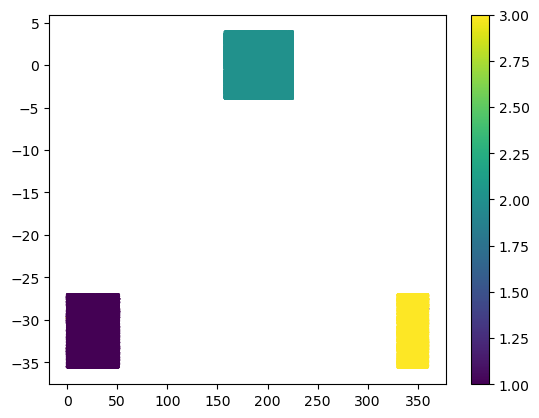

In [9]:
plt.figure()
sc=plt.scatter(df.halora, df.halodec, c=df.footprint, s=1, rasterized=True)
plt.colorbar(sc)
plt.show()

In [10]:
alpha_ij = angular_separation(df['ra'],df['dec'],df['halora'],df['halodec'])
di = cosmo.comoving_transverse_distance(df['redshift_observed']).to('Mpc').value
dj = cosmo.comoving_transverse_distance(df['haloz']).to('Mpc').value
rproj_gal = 0.5 * (di + dj) * alpha_ij
df.loc[:,'rproj_gal'] = rproj_gal

## Examine $R_{\rm proj,gal}$ Distributions

In [11]:
fp1 = df[df.footprint==1]
fp2 = df[df.footprint==2]
fp3 = df[df.footprint==3]

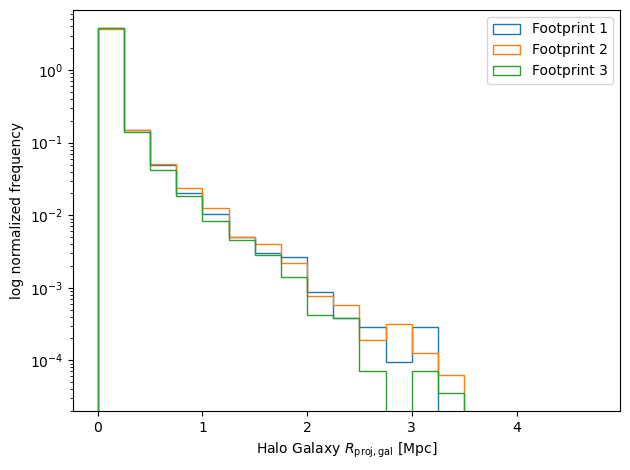

In [16]:
plt.figure()
histkwargs = {'bins':np.arange(0,5,0.25), 'density':True}
plt.hist(fp1.rproj_gal,histtype='step',label='Footprint 1',**histkwargs)
plt.hist(fp2.rproj_gal,histtype='step',label='Footprint 2',**histkwargs)
plt.hist(fp3.rproj_gal,histtype='step',label='Footprint 3',**histkwargs)
plt.yscale('log')
plt.legend(loc='best')
plt.xlabel(r"Halo Galaxy $R_{\rm proj,gal}$ [Mpc]")
plt.ylabel("log normalized frequency")
plt.tight_layout()
plt.savefig("../figures/true_rproj_dists.png",dpi=250)
plt.show()

# Average galaxy density at $M_r \leq -21.8$

In [13]:
fp1.mag_abs_r_SDSS.max(), fp2.mag_abs_r_SDSS.max(), fp3.mag_abs_r_SDSS.max()

(-21.883052825927734, -21.883033752441406, -21.883039474487305)

In [14]:
n1 = len(fp1) / meta['volumes'][0]
n2 = len(fp2) / meta['volumes'][1]
n3 = len(fp3) / meta['volumes'][2]

In [15]:
print('%0.7f' % n1)
print('%0.7f' % n2)
print('%0.7f' % n3)

0.0006397
0.0006868
0.0002347


In [ ]:
print(n1/n2)

In [ ]:
print(n1/n3)

In [ ]:
print(n3/n1)

In [ ]:
s1 = (n1 ** (-1/3.))
s2 = (n2 ** (-1/3.))
s3 = (n3 ** (-1/3.))

In [ ]:
print(s1, s2, s3)

In [ ]:
s3 / s1, s3 / s2